Found 20000 images belonging to 1 classes.
Found 5000 images belonging to 1 classes.


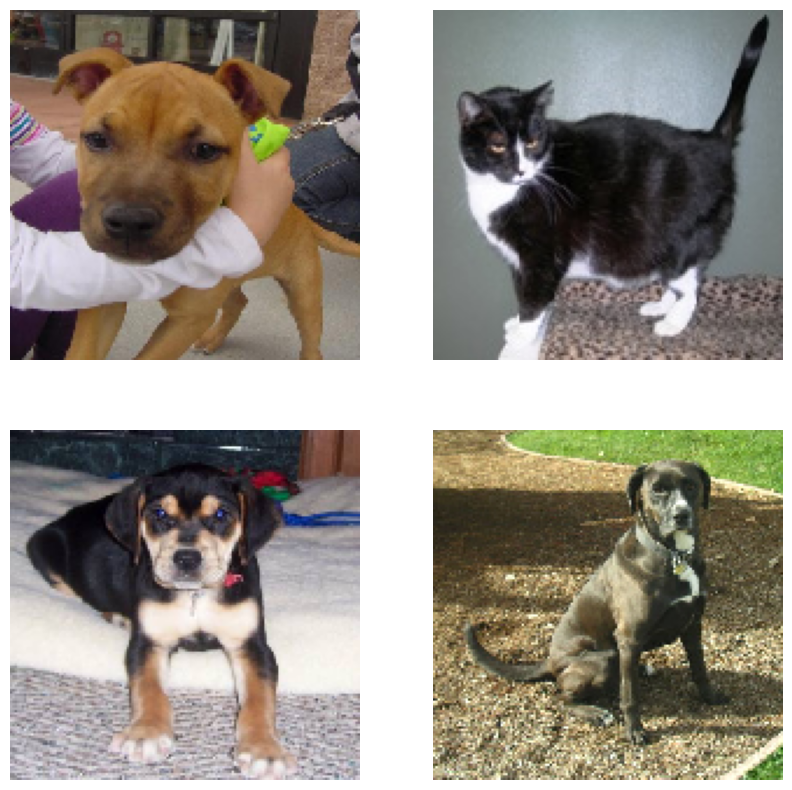

In [ ]:
# DATA AUGMENTATION

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset paths
dataset_path = "kagglecatsanddogs"  
train_dir = os.path.join(dataset_path, "train")
validation_dir = os.path.join(dataset_path, "validation")

# Define image parameters
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Data preprocessing - Loading and splitting dataset
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

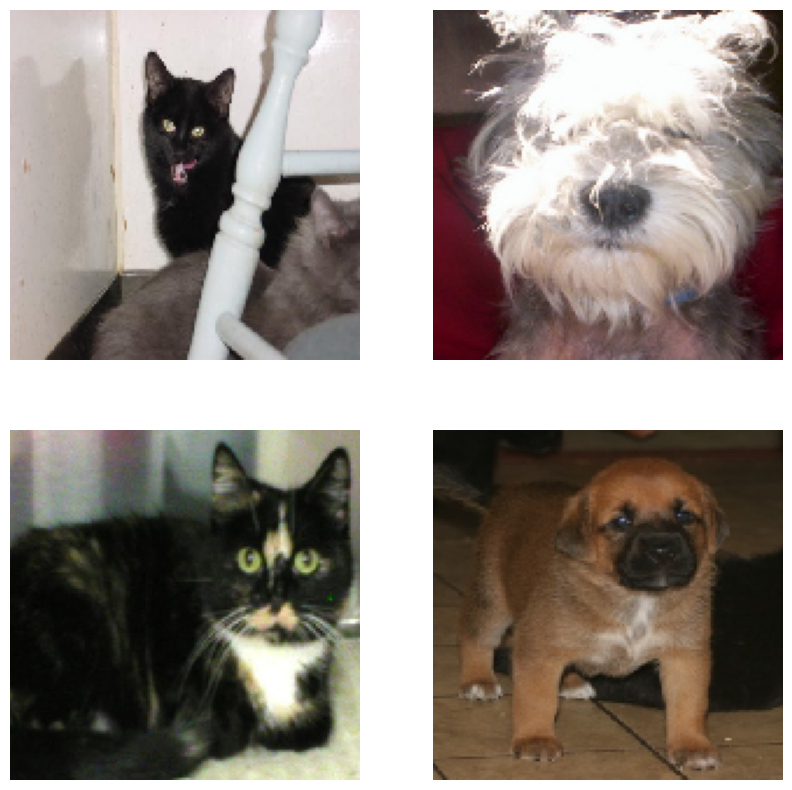

In [4]:
# Exercise 1: Display 4 random images from the dataset
def display_random_images(generator):
    images, labels = next(generator)
    plt.figure(figsize=(10, 10))
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
    plt.show()

display_random_images(train_generator)

TASK 2: APPLYING DATA AUGMENTATION

Found 25000 images belonging to 1 classes.


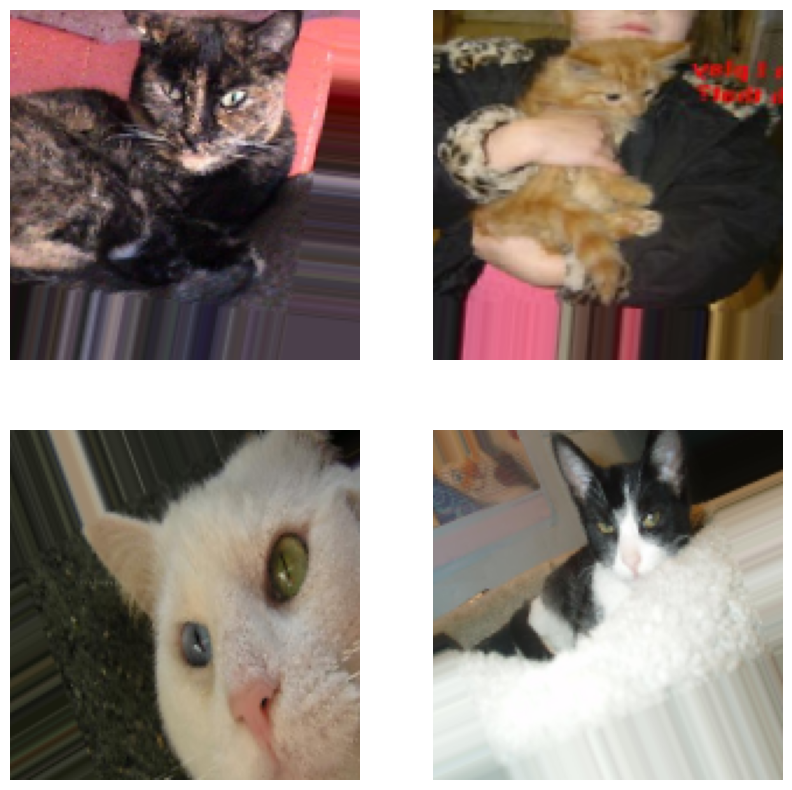

In [ ]:
data_augmentation = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

augmented_train_generator = data_augmentation.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Exercise 2: Display 4 augmented images
def display_augmented_images(generator):
    images, labels = next(generator)
    plt.figure(figsize=(10, 10))
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
    plt.show()

display_augmented_images(augmented_train_generator)

TASK 3: Display images with different augmentation techniques

Found 25000 images belonging to 1 classes.


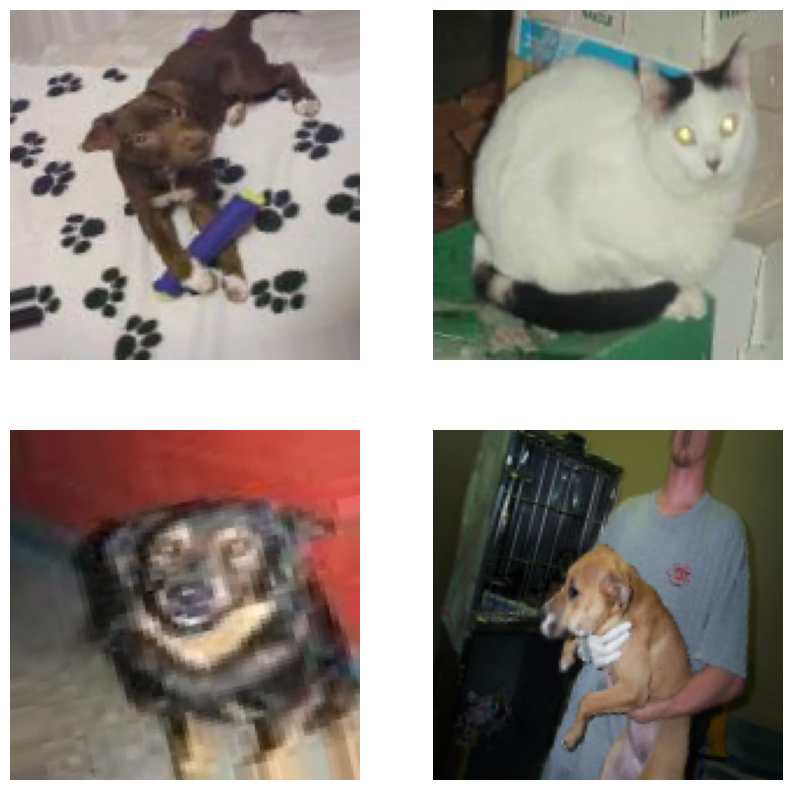

In [7]:
def display_specific_augmented_images(augmentation_type):
    aug_dict = {
        "rotation": ImageDataGenerator(rescale=1./255, rotation_range=40),
        "zoom": ImageDataGenerator(rescale=1./255, zoom_range=0.2),
        "horizontal_flip": ImageDataGenerator(rescale=1./255, horizontal_flip=True),
        "width_shift": ImageDataGenerator(rescale=1./255, width_shift_range=0.2),
    }
    specific_aug = aug_dict.get(augmentation_type, None)
    if specific_aug:
        generator = specific_aug.flow_from_directory(
            dataset_path,
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode='binary',
            subset='training'
        )
        images, labels = next(generator)
        plt.figure(figsize=(10, 10))
        for i in range(4):
            plt.subplot(2, 2, i + 1)
            plt.imshow(images[i])
            plt.axis("off")
        plt.show()

# Example: Display images with only rotation applied
display_specific_augmented_images("rotation")